In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler
)

In [ ]:
df = pd.read_csv("ecommerce_500k.csv")


In [ ]:
print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

DATASET SHAPE
(500000, 30)

DATA TYPES
order_id                     int64
customer_id                  int64
product_id                   int64
order_date                  object
category                    object
sub_category                object
product_base_price         float64
discount_percentage          int64
final_price                float64
quantity                     int64
total_amount               float64
shipping_cost              float64
shipping_method             object
days_to_deliver            float64
payment_method              object
rating                     float64
num_reviews                  int64
customer_age               float64
customer_gender             object
country                     object
city                        object
loyalty_tier                object
is_first_purchase            int64
customer_lifetime_value    float64
session_duration_mins      float64
pages_viewed               float64
clicks_to_purchase           int64
is_returned     

In [ ]:
# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Basic summary
print("\nNUMERICAL SUMMARY")
print(df.describe())


Duplicate Rows: 0

NUMERICAL SUMMARY
           order_id    customer_id     product_id  product_base_price  \
count  5.000000e+05  500000.000000  500000.000000       500000.000000   
mean   1.250000e+06   55007.627196    2503.810058           84.833241   
std    1.443377e+05   25995.094710    1441.201322           79.984198   
min    1.000001e+06   10000.000000       1.000000            5.000000   
25%    1.125001e+06   32490.000000    1259.000000           28.040000   
50%    1.250000e+06   55056.500000    2503.000000           60.220000   
75%    1.375000e+06   77510.000000    3752.000000          115.580000   
max    1.500000e+06   99998.000000    5000.000000         1148.770000   

       discount_percentage    final_price       quantity   total_amount  \
count        500000.000000  500000.000000  500000.000000  500000.000000   
mean             14.599090      72.438608       2.284080     165.605507   
std              12.943309      69.900582       1.739378     237.412198   
min 

In [ ]:
# PHASE 2: SKEWNESS ANALYSIS
# ==========================================

numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

print("\n" + "="*50)
print("SKEWNESS")
print("="*50)

skewness = df[numeric_cols].skew()

print(
    skewness.sort_values(
        ascending=False
    )
)



SKEWNESS
total_amount               4.384068e+00
is_cancelled               3.644618e+00
is_returned                2.341546e+00
final_price                2.107809e+00
session_duration_mins      2.020783e+00
product_base_price         2.008356e+00
customer_lifetime_value    1.990571e+00
shipping_cost              1.987428e+00
quantity                   1.802982e+00
days_to_deliver            1.790739e+00
num_reviews                1.148866e+00
is_first_purchase          9.875454e-01
discount_percentage        7.683761e-01
customer_age               3.524255e-01
order_id                  -1.176893e-15
customer_id               -3.769099e-04
clicks_to_purchase        -1.344258e-03
product_id                -2.117898e-03
pages_viewed              -4.141144e-03
rating                    -9.183888e-01
dtype: float64


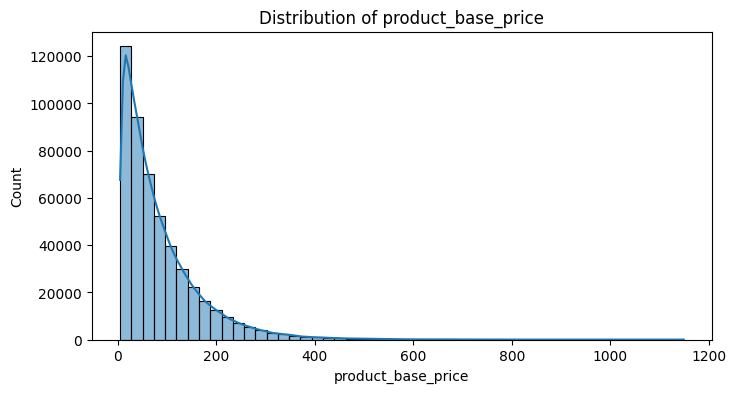

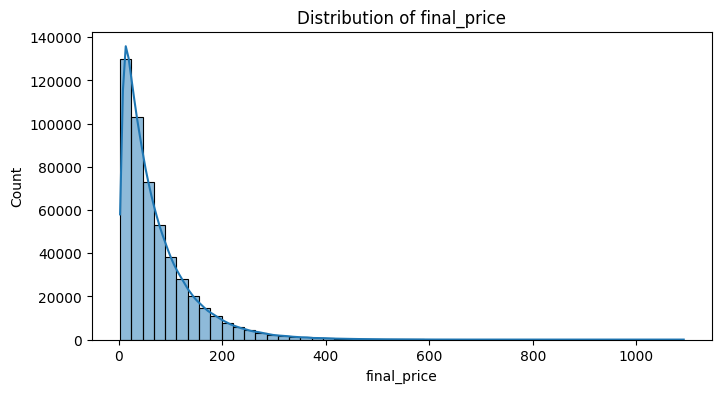

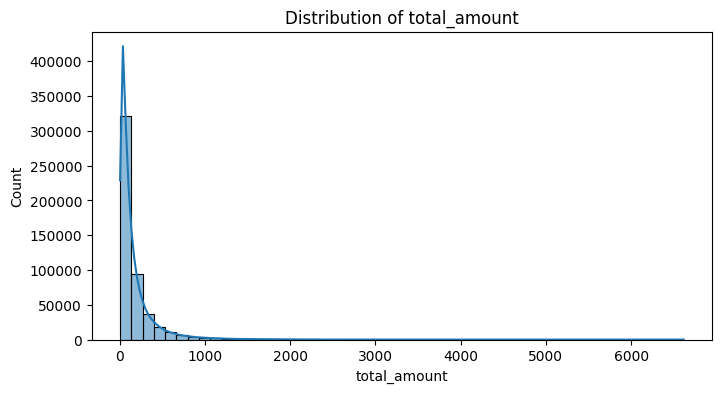

In [ ]:
# Histogram plots

price_cols = [
    'product_base_price',
    'final_price',
    'total_amount'
]

for col in price_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Compare mean vs median

for col in price_cols:

    print(f"\n{col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())


product_base_price
Mean: 84.83324062
Median: 60.22

final_price
Mean: 72.43860782
Median: 50.59

total_amount
Mean: 165.60550651999998
Median: 87.7


In [ ]:
# PHASE 3:
# CATEGORICAL COLUMN INSPECTION
# ==========================================

cat_cols = df.select_dtypes(
    include='object'
).columns

print("\n" + "="*50)
print("CATEGORICAL CARDINALITY")
print("="*50)

for col in cat_cols:

    print(
        f"{col}: {df[col].nunique()} unique values"
    )



CATEGORICAL CARDINALITY
order_date: 1095 unique values
category: 10 unique values
sub_category: 45 unique values
shipping_method: 4 unique values
payment_method: 6 unique values
customer_gender: 3 unique values
country: 8 unique values
city: 15 unique values
loyalty_tier: 4 unique values
return_reason: 5 unique values


In [ ]:
# DATE FEATURE ENGINEERING

df['order_date'] = pd.to_datetime(
    df['order_date']
)

df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek
df['order_quarter'] = df['order_date'].dt.quarter

df['is_weekend'] = np.where(
    df['order_dayofweek'].isin([5,6]),
    1,
    0
)

In [ ]:
# RETURN ANALYSIS
# ==========================================

print("\n" + "="*50)
print("RETURN RATE")
print("="*50)

return_rate = (
    df['is_returned']
    .mean()
    *100
)

print(
    f"Overall Return Rate: {return_rate:.2f}%"
)


RETURN RATE
Overall Return Rate: 11.98%



Category Return Rates
category
Electronics       12.113895
Furniture         12.098325
Beauty            12.057121
Automotive        12.047492
Books             12.041990
Toys              11.942231
Food & Grocery    11.932297
Home & Kitchen    11.894722
Sports            11.864271
Clothing          11.819116
Name: is_returned, dtype: float64


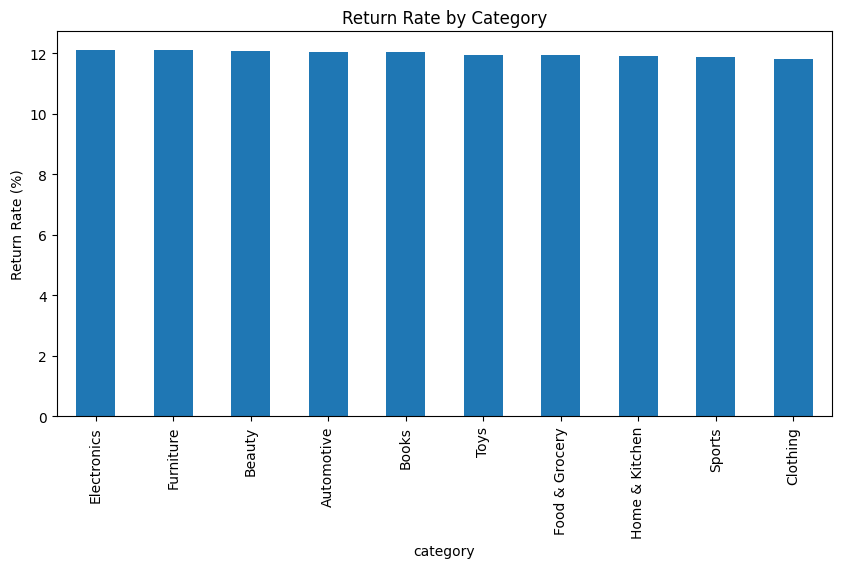

In [ ]:
# Category Return Rates

category_returns = (
    df.groupby('category')['is_returned']
    .mean()
    .sort_values(ascending=False)
    *100
)

print("\nCategory Return Rates")
print(category_returns)

plt.figure(figsize=(10,5))

category_returns.plot(
    kind='bar'
)

plt.title("Return Rate by Category")
plt.ylabel("Return Rate (%)")

plt.show()

In [ ]:
#  Loyalty Tier Returns

tier_returns = (
    df.groupby('loyalty_tier')['is_returned']
    .mean()
    *100
)

print("\nLoyalty Tier Return Rates")
print(tier_returns)


Loyalty Tier Return Rates
loyalty_tier
Bronze      12.028672
Gold        11.982806
Platinum    11.959791
Silver      11.913401
Name: is_returned, dtype: float64


In [ ]:
# Shipping Method Returns

shipping_returns = (
    df.groupby('shipping_method')['is_returned']
    .mean()
    *100
)
print("\nShipping Return Rates")
print(shipping_returns)



Shipping Return Rates
shipping_method
Express     12.003078
Free        11.968165
Same-Day    11.870934
Standard    11.998508
Name: is_returned, dtype: float64


In [ ]:
# Payment Method Returns

payment_returns = (
    df.groupby('payment_method')['is_returned']
    .mean()
    *100
)

print("\nPayment Return Rates")
print(payment_returns)



Payment Return Rates
payment_method
COD            12.035979
Credit Card    12.005766
Debit Card     11.861737
Net Banking    11.878894
UPI            12.028366
Wallet         12.052046
Name: is_returned, dtype: float64


In [ ]:
# PHASE 5:
# FEATURE ENGINEERING
# ==========================================

# Discount amount

df['discount_amount'] = (
    df['product_base_price']
    - df['final_price']
)

# Customer value buckets

df['clv_bucket'] = pd.qcut(
    df['customer_lifetime_value'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

In [ ]:
# Engagement Score

df['engagement_score'] = (
    df['session_duration_mins']
    * df['pages_viewed']
)

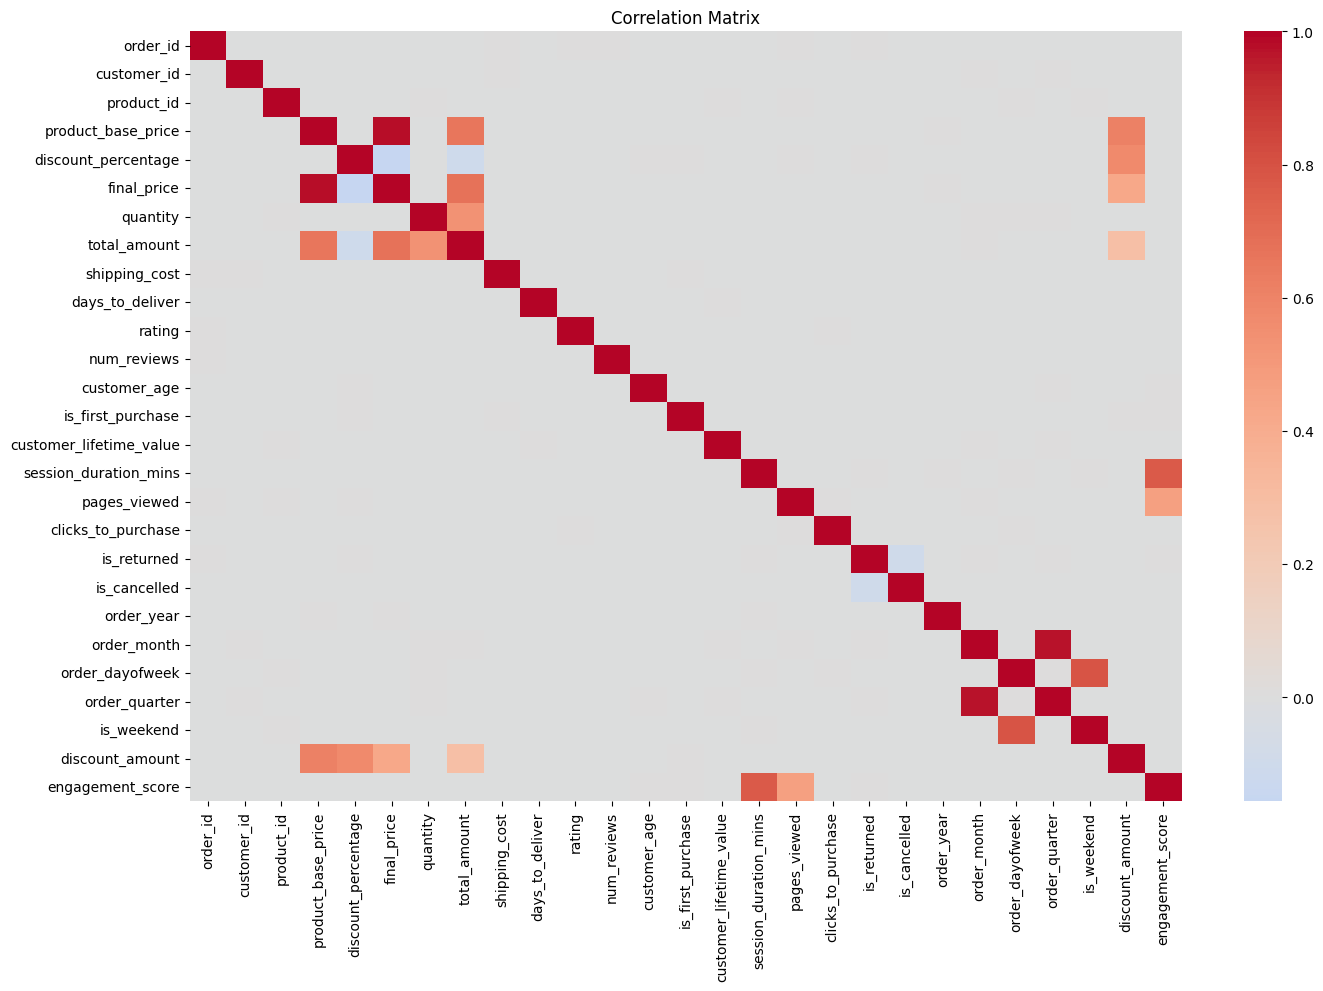

In [ ]:
# PHASE 6:
# CORRELATION ANALYSIS
# ==========================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr_matrix = (
    df[numeric_cols]
    .corr()
)

plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Features correlated with target

target_corr = (
    corr_matrix['is_returned']
    .sort_values(
        ascending=False
    )
)

print("\nCorrelation With Return Target")
print(target_corr)


Correlation With Return Target
is_returned                1.000000
order_month                0.002940
discount_percentage        0.002670
order_quarter              0.002505
order_id                   0.002068
session_duration_mins      0.002037
engagement_score           0.001695
pages_viewed               0.001297
is_first_purchase          0.001002
days_to_deliver            0.000614
discount_amount            0.000431
customer_lifetime_value    0.000235
order_year                -0.000004
quantity                  -0.000420
customer_age              -0.000679
num_reviews               -0.000858
clicks_to_purchase        -0.000995
customer_id               -0.001203
shipping_cost             -0.001265
product_base_price        -0.001294
product_id                -0.001383
total_amount              -0.001512
final_price               -0.001599
order_dayofweek           -0.002057
is_weekend                -0.002977
rating                    -0.004459
is_cancelled              -0.094

In [ ]:
# Highly correlated pairs

print("\nHighly Correlated Features (>0.80)")

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        corr_value = corr_matrix.iloc[i,j]

        if abs(corr_value) > 0.80:

            print(
                corr_matrix.columns[i],
                "<->",
                corr_matrix.columns[j],
                ":",
                round(corr_value,3)
            )



Highly Correlated Features (>0.80)
final_price <-> product_base_price : 0.976
order_quarter <-> order_month : 0.971


In [ ]:
# PREPROCESSING PIPELINE
# ==========================================

numeric_features = [
    'product_base_price',
    'discount_percentage',
    'final_price',
    'quantity',
    'total_amount',
    'shipping_cost',
    'days_to_deliver',
    'rating',
    'num_reviews',
    'customer_age',
    'customer_lifetime_value',
    'session_duration_mins',
    'pages_viewed',
    'clicks_to_purchase',
    'discount_amount',
    'engagement_score'
]

ordinal_features = [
    'loyalty_tier'
]

categorical_features = [
    'category',
    'sub_category',
    'shipping_method',
    'payment_method',
    'customer_gender',
    'country',
    'city'
]

In [ ]:
# Numeric Pipeline

numeric_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        RobustScaler()
    )
])

In [ ]:
# Ordinal Pipeline

ordinal_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent'
        )
    ),
    (
        'ordinal',
        OrdinalEncoder(
            categories=[
                [
                    'Bronze',
                    'Silver',
                    'Gold',
                    'Platinum'
                ]
            ]
        )
    )
])

In [ ]:
# Categorical Pipeline

categorical_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent'
        )
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [ ]:
# Final ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_pipeline,
            numeric_features
        ),
        (
            'ord',
            ordinal_pipeline,
            ordinal_features
        ),
        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("\nPipeline Created Successfully")


Pipeline Created Successfully


In [ ]:
# TRANSFORM FEATURES
# ==========================================

X = df.drop(
    columns=[
        'is_returned',
        'order_id',
        'customer_id',
        'product_id',
        'order_date',
        'return_reason'
    ],
    errors='ignore'
)

y = df['is_returned']

X_processed = preprocessor.fit_transform(X)

print("\nProcessed Shape:")
print(X_processed.shape)

print("\nEDA & Feature Engineering Complete")


Processed Shape:
(500000, 108)

EDA & Feature Engineering Complete
